# Controlled changes — novelty criterion, prior work, reasoning, idea format

Rows = ablations, columns = judge models, one column block per data track. Each
cell is what one ablation did to one judge, with `*` for significant at 95%
(corpus-level paired bootstrap, n=100,000). The strip on top is the un-ablated
baseline the whole block is measured against.

Reads the `unified_*.json` chart data `merge_ablation_runs.py` writes — no merge
re-run, no bootstrap here. Writes a PDF (vector, for the paper) and a PNG (shown
inline below) to `output/figures/<FIGURE>/`, once for each of the two readings
below.

The figure itself — the layout, the palettes, which cells are artefacts — is
`common.TwoTrackFigure`, so this notebook holds only the wording of one
experiment and a figure drawn here cannot disagree with one drawn by a script.
[prompt_design_figure.ipynb](prompt_design_figure.ipynb) is the same figure over
the prompt-design runs.

In [17]:
import sys
from pathlib import Path

from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src").is_dir() and (p / "output").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from novelty_eval.figures.common import TwoTrackFigure

print(ROOT)

/Users/noysternlicht/myCode/novelty-eval


## What the figure says

Everything that decides what this figure says is in the next cell: nothing below
it needs editing to change the experiment. `{setup}` and `{track}` expand per
track — the plan-form ablation runs on a different instance set in each, so its
panel is named per track while the others are named the same in both. A row can
also name the setups it belongs to: P3–P5 were only run pairwise, so they are
drawn in the pairwise figures and left out of the pointwise ones. `row_groups`
brackets rows that vary the same thing, named by panel name rather than by
position, so the pointwise figure brackets only the rows it drew.

In [18]:
FIG = TwoTrackFigure(
    root=ROOT,
    figure="controlled-study",        # output subdirectory and filename prefix
    # (block title, merge dir under output/ablation_sweeps, name token)
    tracks=[("Human-only", "merge_hvh_all_metrics", "human"),
            ("Human + generated", "merge_vanilla_all_metrics", "vanilla")],
    # (panel name, row label[, setups the row belongs to]), top to bottom
    # A row label wraps where it would otherwise widen the whole figure: the
    # left margin is sized to the longest one, and a row is tall enough for two
    # lines of it.
    rows=[("vague_criterion", "P1 · Criteria without\nguardrails"),
          ("no_criteria_prompt", "P2 · Criteria removed"),
          # P3-P5 were only run pairwise, so they are drawn there only.
          ("ai_researcher_base", 'P3 · "Which was\njudged novel?"', ("pairwise",)),
          ("ai_researcher_no_review", 'P4 · "Which is novel?"', ("pairwise",)),
          ("ai_researcher_comparative", 'P5 · "Which was judged\n more novel?"', ("pairwise",)),
          ("retrieval", "+ Related work\n(retrieval)"),
          ("low_judge_reasoning", "Reasoning effort = low"),
          ("convert_to_plan_form_{setup}_{track}", "Idea as research plan")],
    # judge columns, left to right
    models=["claude-sonnet-4-5", "claude-opus-4-5", "claude-opus-4-6",
            "gpt-5.1", "gpt-5.2", "gpt-5.4"],
    # the two setups score different things, so each names its own metric
    metrics={"pairwise": "pairwise_accuracy", "pointwise": "f1_neg"},
    row_axis_label="Change",
    # (group label, the panel names in it), bracketed in the left margin.
    row_groups=[("Judge prompt", ("vague_criterion", "no_criteria_prompt",
                                  "ai_researcher_base", "ai_researcher_no_review",
                                  "ai_researcher_comparative"))],
    baseline_label="Reference",        # the un-ablated strip, named like a row
)

## The numbers

`FIG.table(setup)` is the whole data path: one tidy row per (track, ablation,
judge), everything already in points. Print it, sort it, `.query()` it — if a
cell in the figure looks wrong, the reason is visible here, before any drawing
happens.

A missing panel, or a cell `common.UNSUPPORTED_CELLS` blanks (a judge that
cannot honour the ablation), gives `NaN` and draws as `—`.

In [19]:
print(FIG.table(next(iter(FIG.metrics))).to_string())

                track                               ablation       judge  baseline  ablated  delta  significant
0          Human-only      P1 · Criteria without\nguardrails  sonnet-4-5     80.19    78.57  -1.62        False
1          Human-only      P1 · Criteria without\nguardrails    opus-4-5     81.49    80.52  -0.97        False
2          Human-only      P1 · Criteria without\nguardrails    opus-4-6     82.79    82.47  -0.32        False
3          Human-only      P1 · Criteria without\nguardrails     gpt-5.1     87.01    85.39  -1.62        False
4          Human-only      P1 · Criteria without\nguardrails     gpt-5.2     85.39    84.09  -1.30        False
5          Human-only      P1 · Criteria without\nguardrails     gpt-5.4     85.39    82.14  -3.25        False
6          Human-only                  P2 · Criteria removed  sonnet-4-5     80.19    77.92  -2.27        False
7          Human-only                  P2 · Criteria removed    opus-4-5     81.49    84.09   2.60      

## The figure: what each change did

One `pcolormesh` per track, then the cell text on top of it. Diverging red→green
scale centred on zero and shared across both blocks, so a colour means the same
thing left and right; every cell also prints its number, so colour is never the
only encoding. A number is set bold where the change is significant, so the
significant cells are findable without reading an asterisk. The baseline strip
is drawn outside the grid, in a shade of its own, so it never reads as a delta
of zero — and it is not a claim about a change, so it is set regular.

output/figures/controlled-study/controlled-study_pairwise_filtered_pairwise_accuracy.png (+ .pdf)


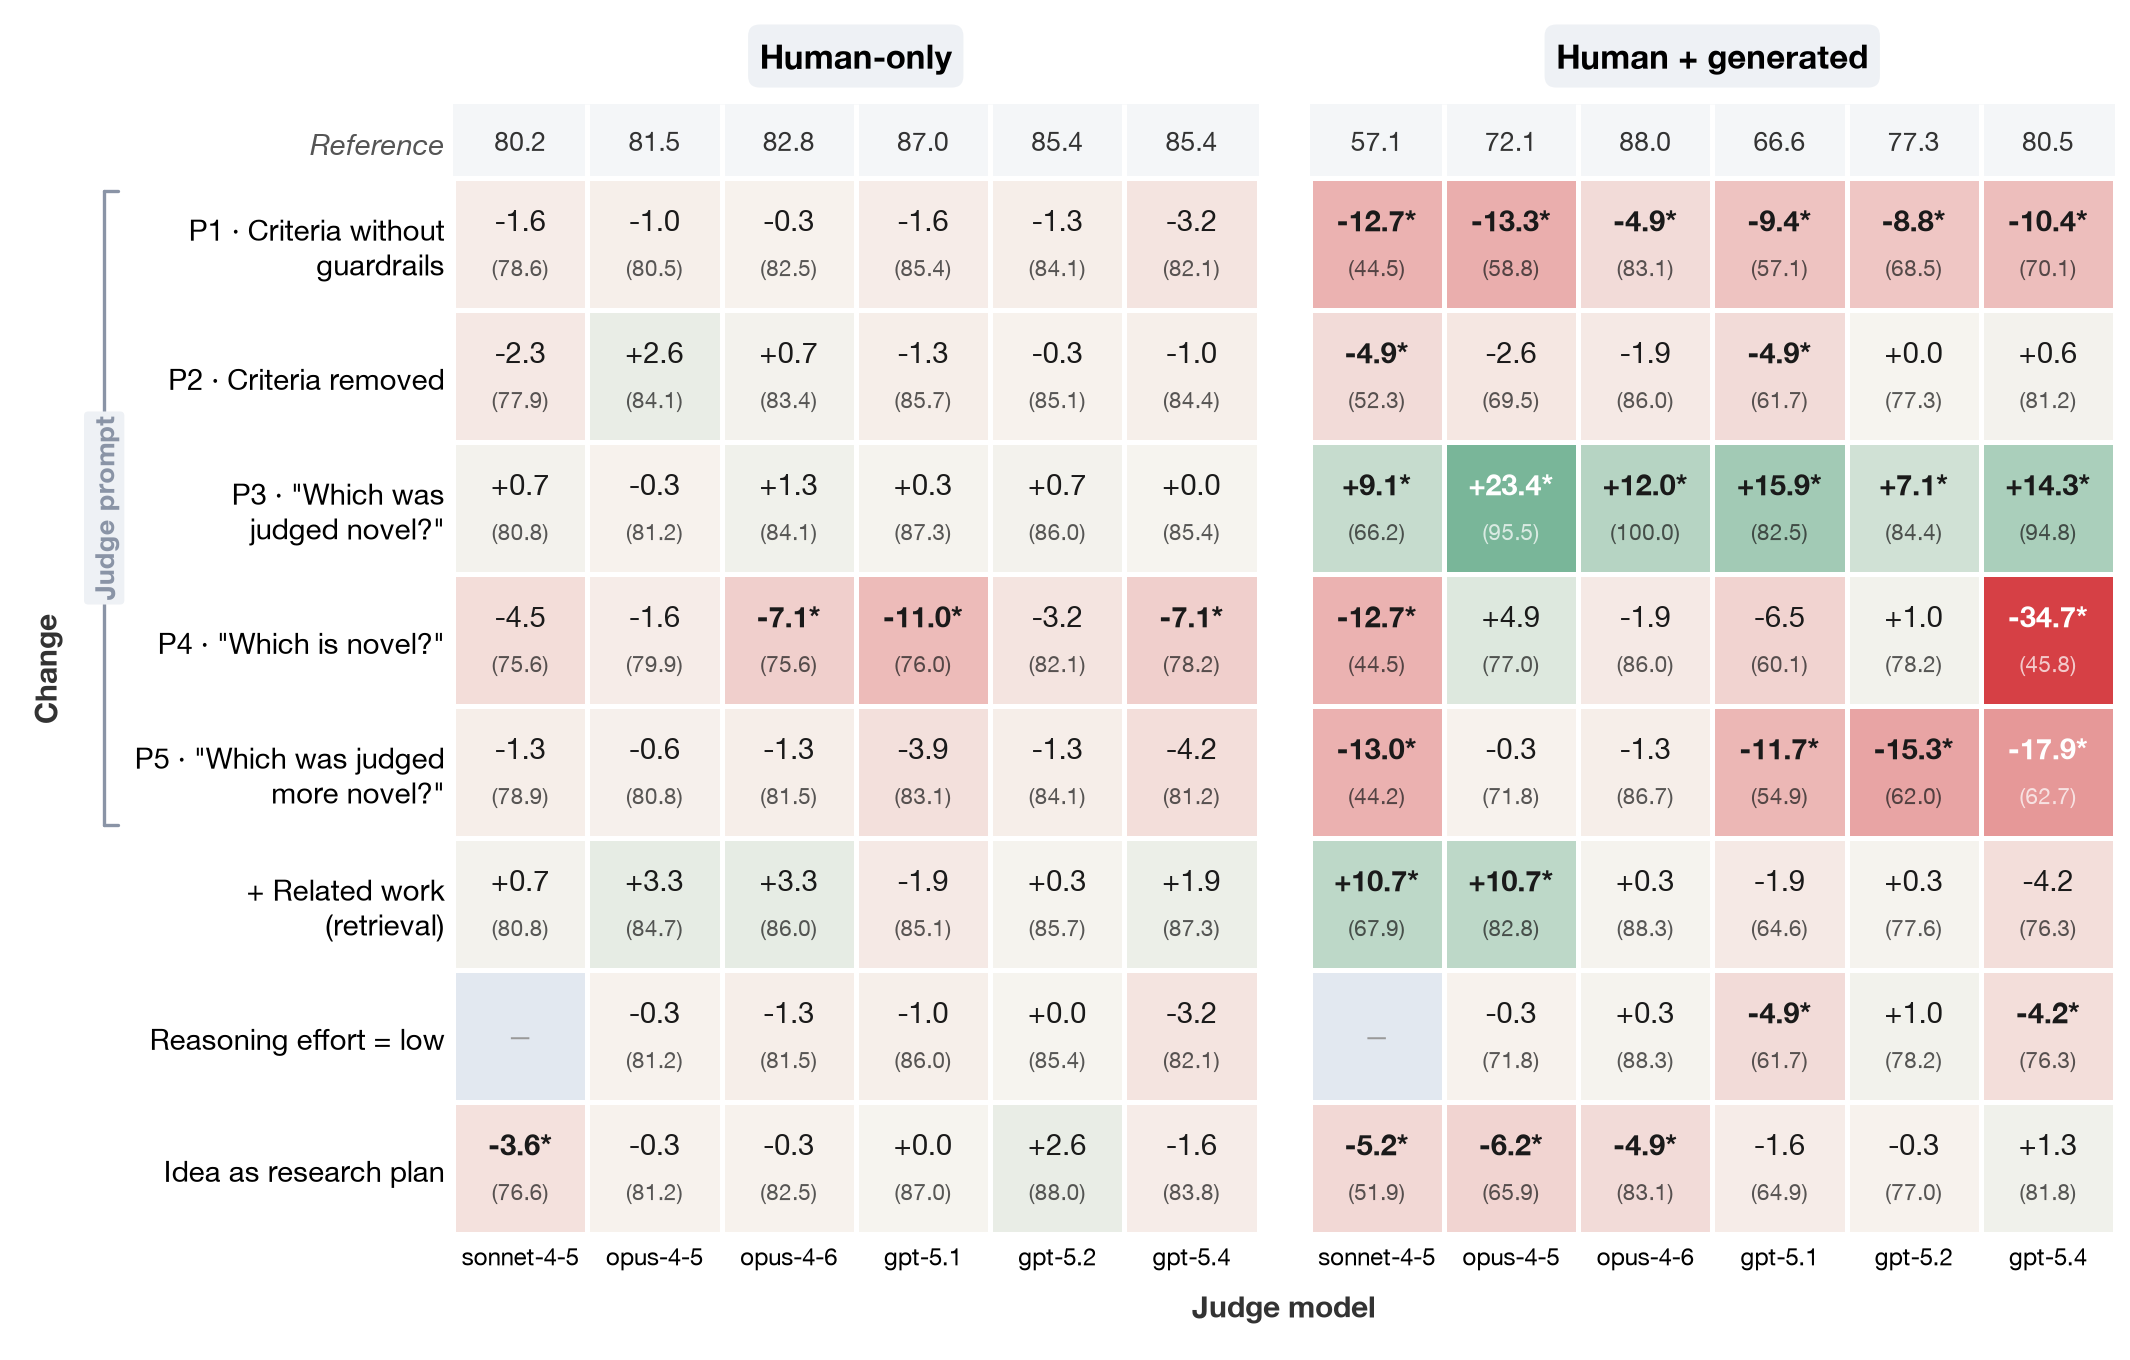

output/figures/controlled-study/controlled-study_pointwise_filtered_f1_neg.png (+ .pdf)


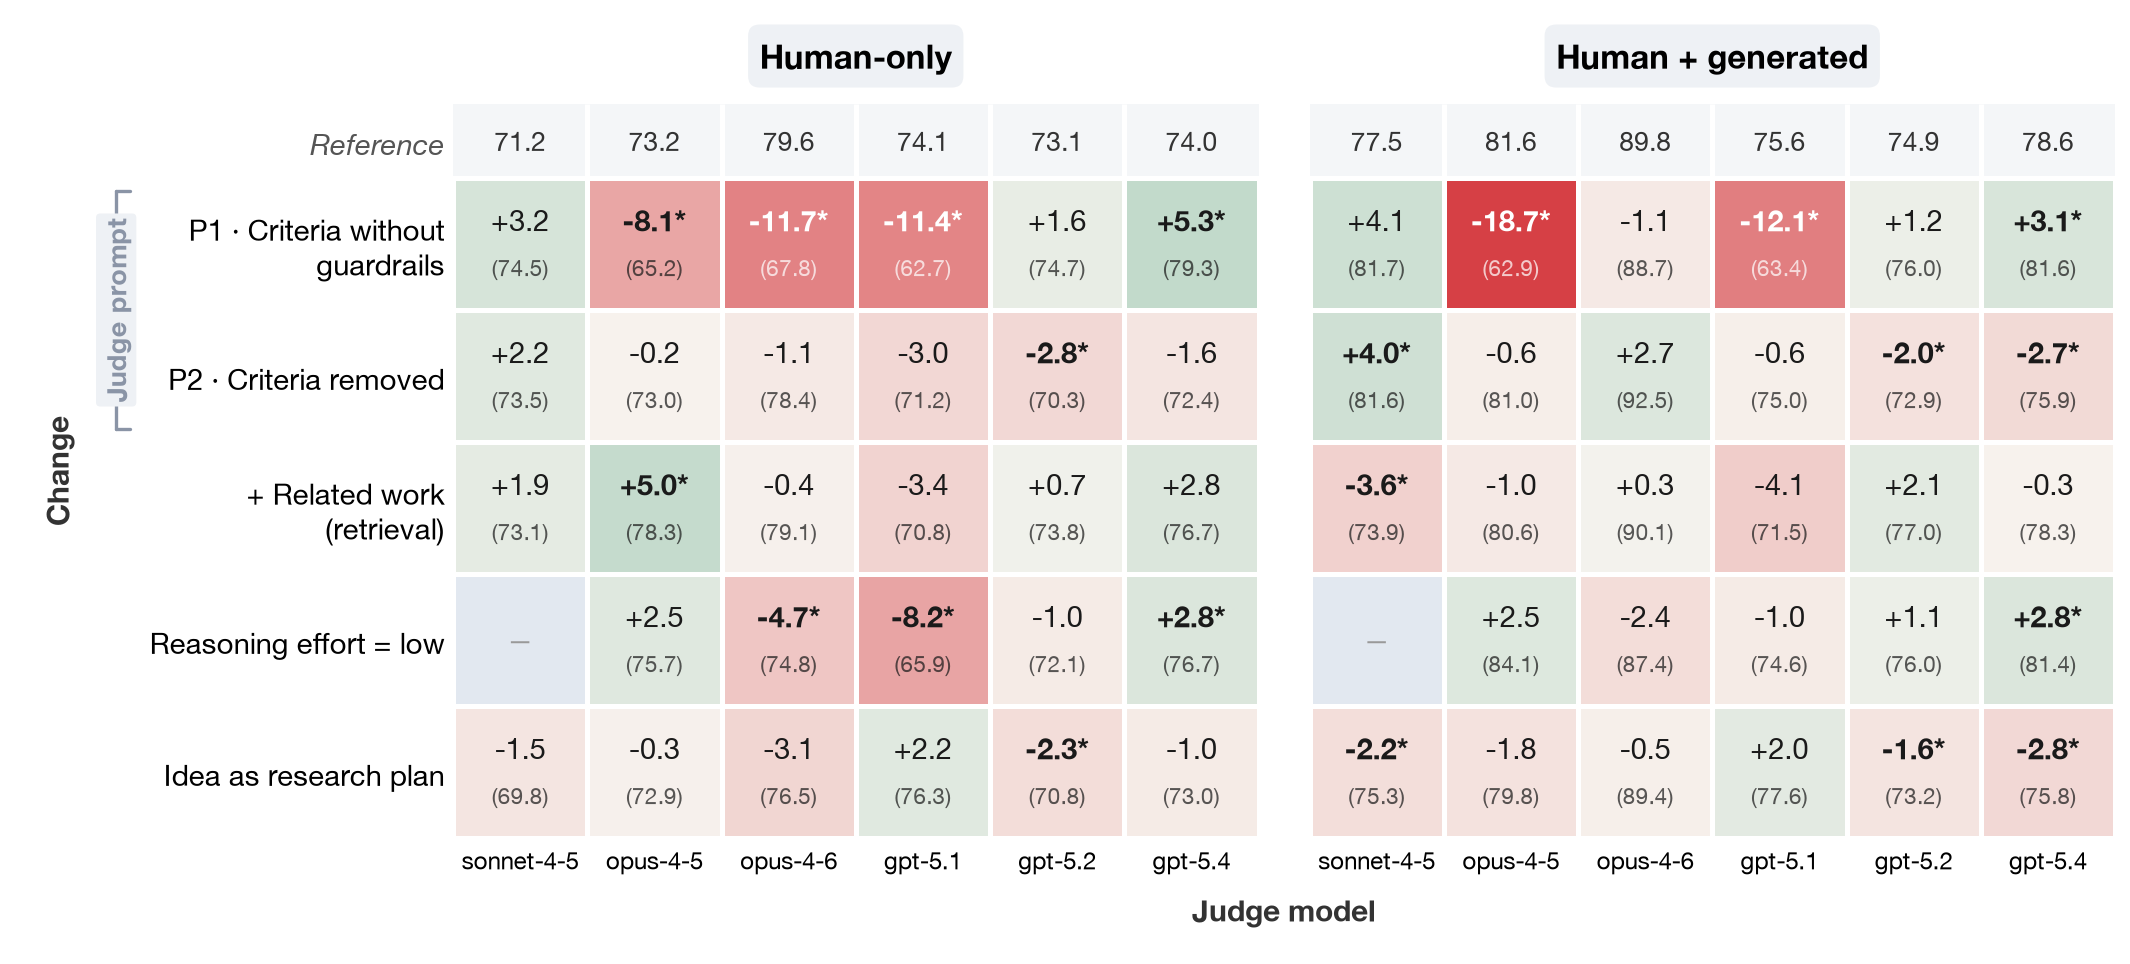

In [20]:
for setup in FIG.metrics:
    png = FIG.draw(setup)
    print(png.relative_to(ROOT), "(+ .pdf)")
    display(Image(filename=str(png)))

## The same numbers, absolute

The figure above colours the *change*, which hides where a judge started: two
judges that both drop 3 points look alike whether they land at 80 or at 55. This
is the same table and the same red→green scale, but a cell is the score itself
and nothing else, and the baseline is an ordinary row of the grid rather than a
strip measured against.

White is 50 — chance on a two-way decision — so red is a judge below it and
green one above, and the scale is symmetric about that rather than stretched to
whatever range this figure happens to cover. No significance markers, and no
bold: that is a claim about the *change*, so it is made in the figure above.
Written next to it with an `_absolute` suffix.

In [21]:
# for setup in FIG.metrics:
#     png = FIG.draw_absolute(setup)
#     print(png.relative_to(ROOT), "(+ .pdf)")
#     display(Image(filename=str(png)))